
  BITCOIN (BTC) vs FTSE ADX GENERAL INDEX — IMPACT ANALYSIS

  Detected files:
    FTSE ADX Index : /content/FTSE ADX General Historical Data.csv
    Bitcoin        : ./Bitcoin Historical Data_crypto.csv

  Data loaded: 86 overlapping trading days (weekends dropped)
  Period : Jan 2019 → Feb 2026

      Date  BTC_Return  ADX_Return
2019-01-01     -0.0734      0.0264
2019-02-01      0.1104      0.0184
2019-03-01      0.0749     -0.0123
2019-04-01      0.2970      0.0361
2019-05-01      0.6085     -0.0484
  ...

  SECTION 2 — DESCRIPTIVE STATISTICS
            Count    Mean     Std     Min     25%     50%     75%     Max
BTC_Return   86.0  0.0508  0.1904 -0.3732 -0.0718  0.0260  0.1393  0.6085
ADX_Return   86.0  0.0099  0.0450 -0.2380 -0.0103  0.0134  0.0287  0.1327

  Pearson Correlation (Bitcoin vs FTSE ADX): 0.1636


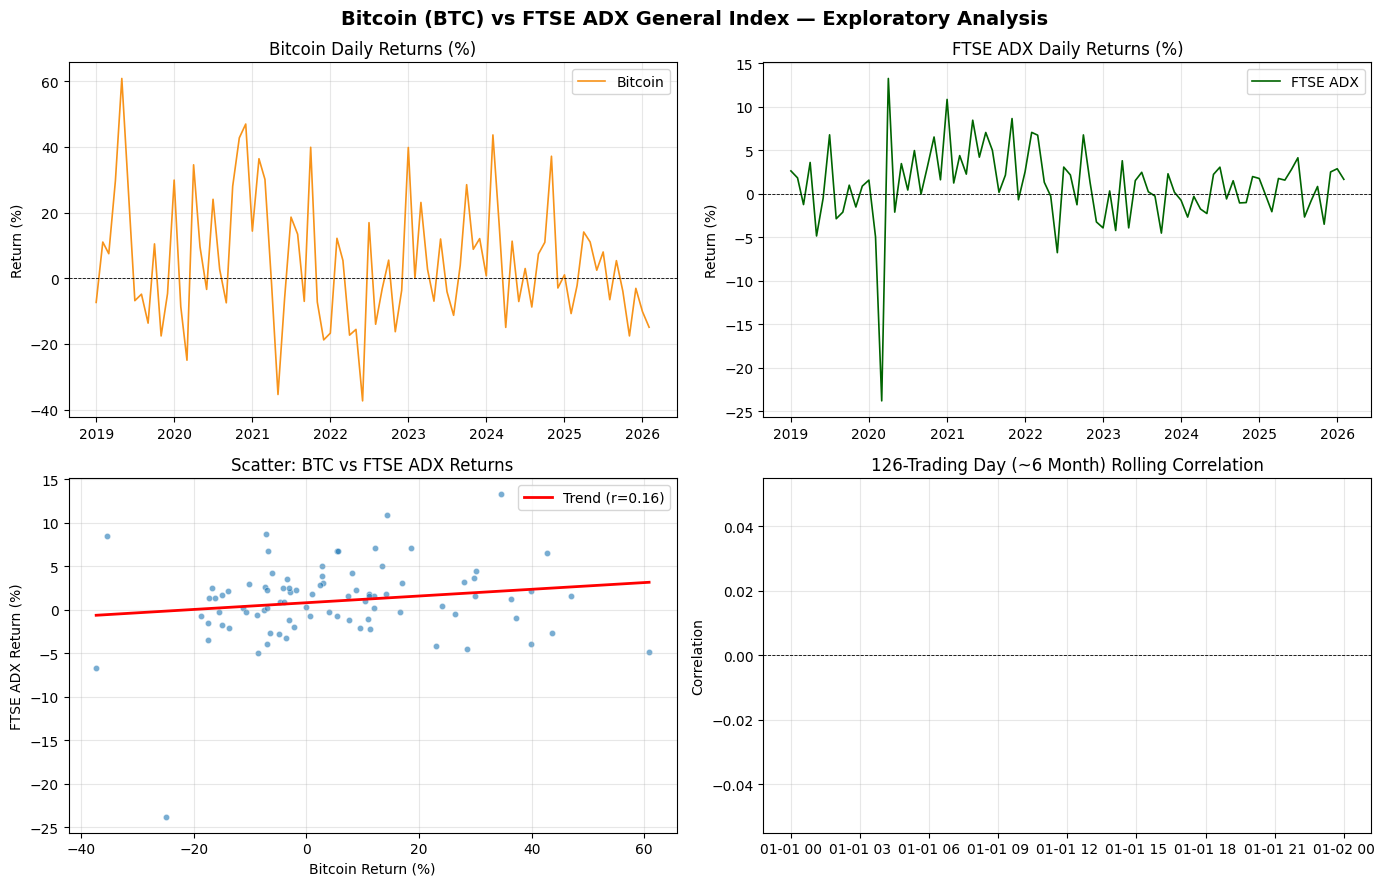


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average Bitcoin Return  (X̄) = 5.0826%
    Average FTSE ADX Return (Ȳ) = 0.9859%

  Step 4 — Slope β
    β = 0.0386
    → For every 1% rise in BTC, ADX changes by ~0.0386%

  Step 5 — Intercept α = 0.007896

  Step 6 — Regression Equation
    ADX_Return = 0.007896 + 0.0386 × BTC_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 0.0254
    t-statistic = 1.5201
    p-value     = 0.1322
    95% CI      = [-0.0119, 0.0892]
    ✘ NOT significant — Fail to reject H₀

  Step 8 — Goodness of Fit
    R² = 0.0268  (2.68% of ADX variation explained by BTC)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:             ADX_Return   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:    

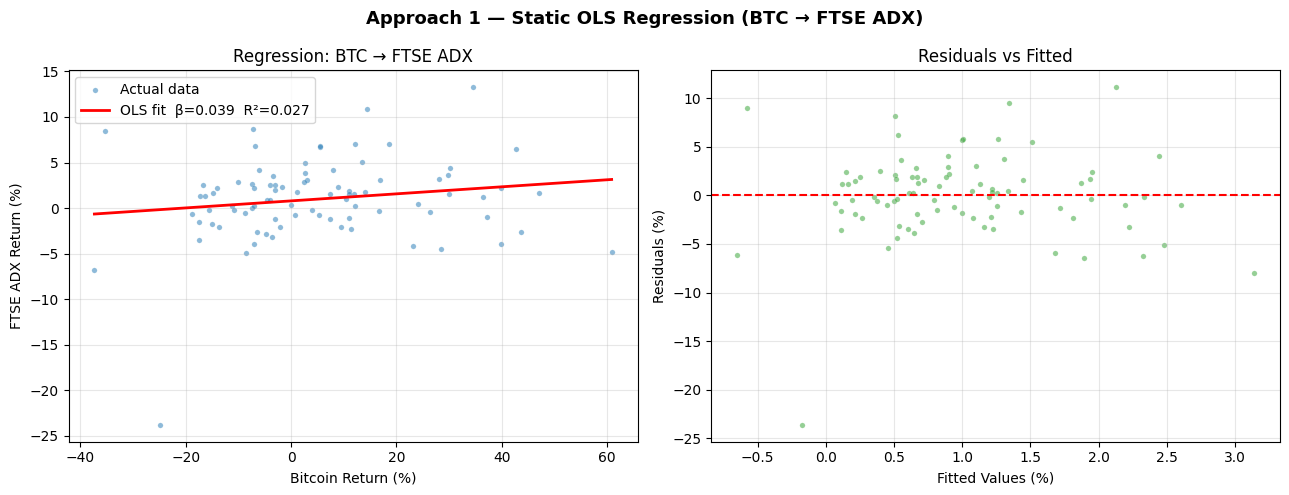


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    BTC Return                | ADF stat =  -7.300 | p = 0.0000 | ✔ Stationary
    FTSE ADX Return           | ADF stat =  -9.707 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of ADX Returns
    Lag-1 autocorrelation: -0.0628
    Lag-2 autocorrelation: 0.1050
    Low autocorrelation — lagged term adds robustness

  Step 4 & 5 — Building Dynamic Regression Model
    Model: ADX_t = α + β×BTC_t + γ×ADX_(t-1)

    Estimated equation:
    ADX_t = 0.00807 + 0.0382×BTC_t + -0.0413×ADX_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=0.0382  t=1.472  p=0.1448  ✘ Not significant
    Lag effect   (γ): coef=-0.0413  t=-0.377  p=0.7071  ✘ Not significant

    R² (dynamic model) = 0.0296
    Adj. R²            = 0.0059

  Step 7 — Granger Causality Test
    H₀: BTC returns do NOT Granger-cause FTSE ADX returns
    Sample size: 86 obs → testin

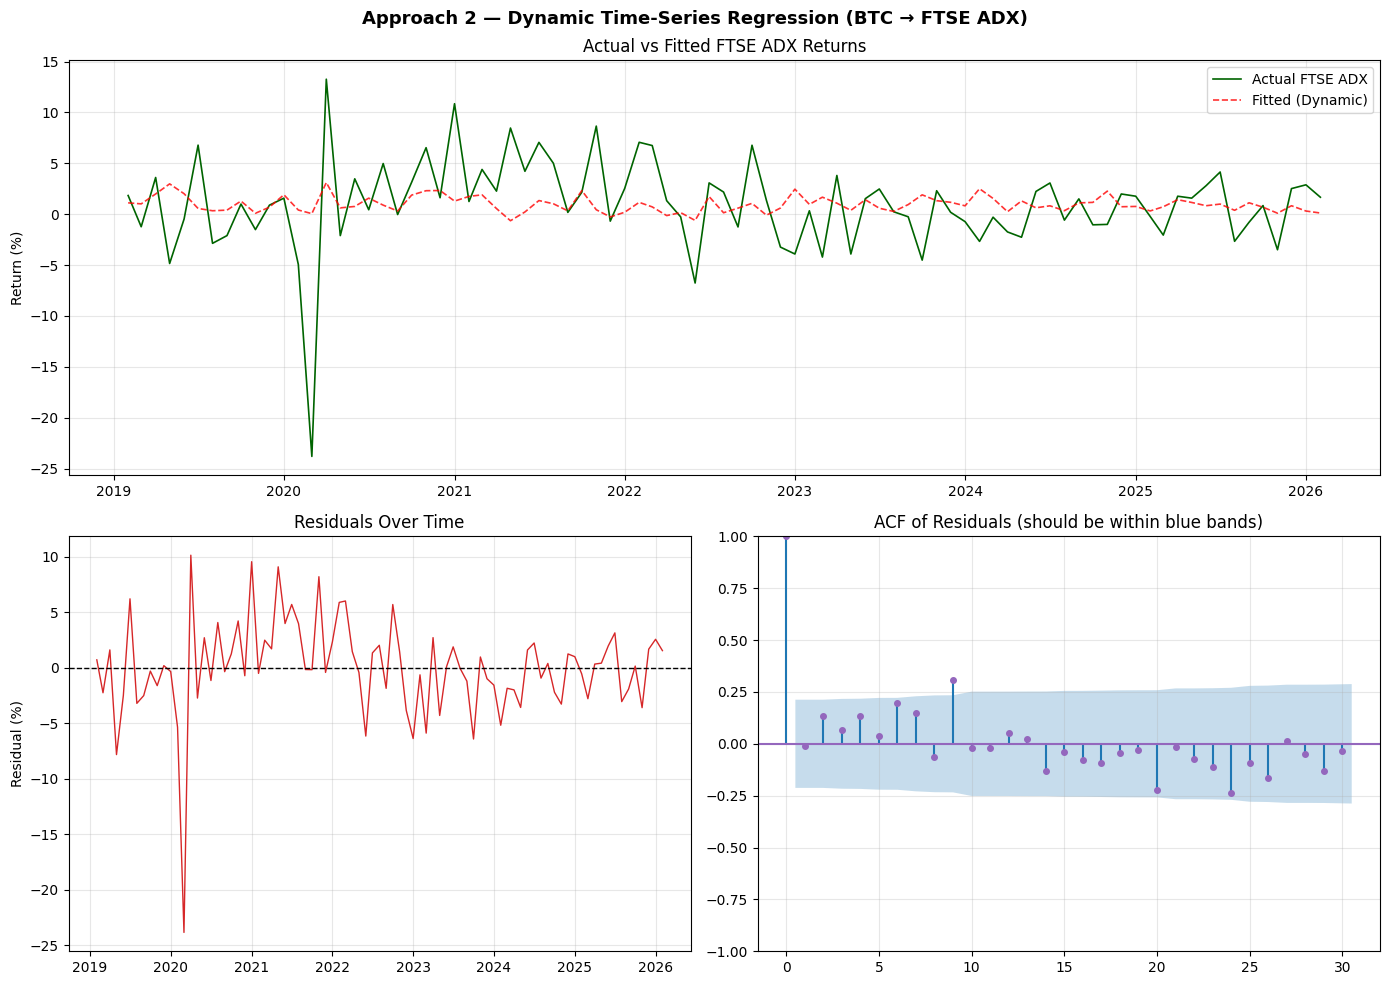


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                  0.0386                    0.0382
Lag Term (γ)                Not included                   -0.0413
p-value (crypto)                  0.1322                    0.1448
R²                                0.0268                    0.0296
Accounts for Memory?                  No                       Yes


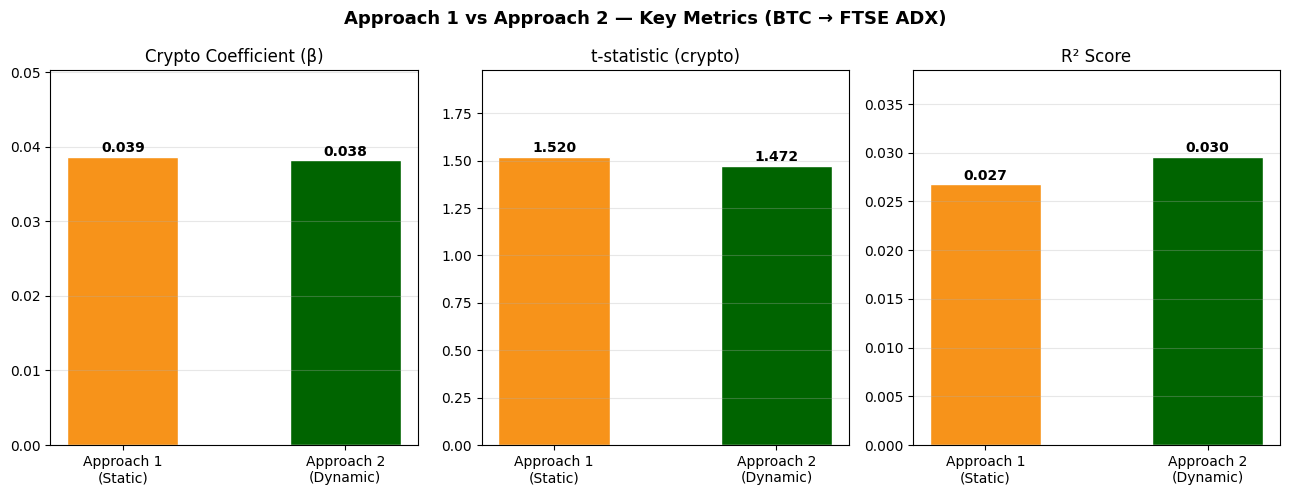


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION & ECONOMETRIC CONSIDERATIONS

  Analysis of Bitcoin (BTC) impact on FTSE ADX General Index (UAE):

  ▸ Approach 1 (Static OLS):
      β = 0.0386 — a 1% BTC change correlates with ~0.039% ADX change
      R² = 0.0268
      Result: NOT SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = 0.0382 — immediate effect after controlling for momentum
      γ = -0.0413 — -4.1% of prior period's ADX return persists
      R² = 0.0296
      Result: NOT SIGNIFICANT

  CRITICAL LOGICAL CONSIDERATIONS FOR THE UAE MARKET:
  1. The Currency Peg: Unlike Argentina or Turkey, the UAE Dirham (AED) is strictly 
     pegged to the US Dollar. Therefore, there is no "inflation illusion" or currency 
     devaluation driving nominal prices up. Both BTC and ADX can be evaluated cleanly.
  2. Distinct Macro Drivers: The FTSE ADX is heavily driven by global energy prices 
     (Brent Crude Oil), regional banking revenues, and real estate (e.g., Aldar). 

In [ ]:
# ============================================================
#   BITCOIN (BTC) vs FTSE ADX GENERAL INDEX — IMPACT ANALYSIS
# ============================================================

# STEP 0: Install dependencies
import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])


import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")


search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please ensure both FTSE ADX and Bitcoin CSV files are present in the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )


ADX_FILE = next((f for f in csv_files if "ADX" in os.path.basename(f) or "FTSE" in os.path.basename(f) or "General" in os.path.basename(f)), None)
BTC_FILE = next((f for f in csv_files if "Bitcoin" in os.path.basename(f) or "bitcoin" in os.path.basename(f)
                                         or "crypto" in os.path.basename(f) or "BTC" in os.path.basename(f)), None)


if ADX_FILE is None or BTC_FILE is None:
    remaining = [f for f in csv_files if f not in (ADX_FILE, BTC_FILE)]
    if ADX_FILE is None and remaining:
        ADX_FILE = remaining.pop(0)
    if BTC_FILE is None and remaining:
        BTC_FILE = remaining.pop(0)

if ADX_FILE is None or BTC_FILE is None:
    raise FileNotFoundError(
        "Could not identify both FTSE ADX and Bitcoin CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'ADX'/'FTSE' and 'Bitcoin'/'crypto'."
    )

print("\n" + "=" * 65)
print("  BITCOIN (BTC) vs FTSE ADX GENERAL INDEX — IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    FTSE ADX Index : {ADX_FILE}")
print(f"    Bitcoin        : {BTC_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()

    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)

    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

btc = load_and_clean(BTC_FILE, "BTC_Return")
adx = load_and_clean(ADX_FILE, "ADX_Return")


data = pd.merge(btc, adx, on="Date", how="inner")
data = data.sort_values("Date").dropna().reset_index(drop=True)

print(f"\n  Data loaded: {len(data)} overlapping trading days (weekends dropped)")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "BTC_Return", "ADX_Return"]].head().to_string(index=False))
print("  ...")

# ============================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["BTC_Return", "ADX_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(4).to_string())

corr = data["BTC_Return"].corr(data["ADX_Return"])
print(f"\n  Pearson Correlation (Bitcoin vs FTSE ADX): {corr:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Bitcoin (BTC) vs FTSE ADX General Index — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["BTC_Return"] * 100, color="#F7931A", label="Bitcoin", linewidth=1.2) # Bitcoin Orange
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Bitcoin Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["ADX_Return"] * 100, color="#006400", label="FTSE ADX", linewidth=1.2) # Dark Green for UAE
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("FTSE ADX Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["BTC_Return"] * 100, data["ADX_Return"] * 100,
           alpha=0.6, color="#1f77b4", edgecolors="white", linewidth=0.4, s=20)
m, b = np.polyfit(data["BTC_Return"], data["ADX_Return"], 1)
x_line = np.linspace(data["BTC_Return"].min(), data["BTC_Return"].max(), 100)
ax.plot(x_line * 100, (m * x_line + b) * 100, color="red", linewidth=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("FTSE ADX Return (%)")
ax.set_title("Scatter: BTC vs FTSE ADX Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]

roll_corr = data["BTC_Return"].rolling(126).corr(data["ADX_Return"])
ax.plot(data["Date"], roll_corr, color="#006400", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("126-Trading Day (~6 Month) Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["BTC_Return"]
Y = data["ADX_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average Bitcoin Return  (X̄) = {x_mean*100:.4f}%")
print(f"    Average FTSE ADX Return (Ȳ) = {y_mean*100:.4f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in BTC, ADX changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")

print(f"\n  Step 6 — Regression Equation")
print(f"    ADX_Return = {alpha:.6f} + {beta:.4f} × BTC_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse["BTC_Return"]
t_stat    = ols_model.tvalues["BTC_Return"]
p_value   = ols_model.pvalues["BTC_Return"]
ci        = ols_model.conf_int().loc["BTC_Return"]

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")
print(f"    95% CI      = [{ci[0]:.4f}, {ci[1]:.4f}]")
if abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.2f}% of ADX variation explained by BTC)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (BTC → FTSE ADX)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.5, color="#1f77b4", edgecolors="white", linewidth=0.2, s=15, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("FTSE ADX Return (%)")
ax.set_title("Regression: BTC → FTSE ADX")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.5, color="#2ca02c", edgecolors="white", linewidth=0.2, s=15)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["BTC_Return"], "BTC Return"),
                     (data["ADX_Return"], "FTSE ADX Return")]:
    adf_result = adfuller(series.dropna())
    stat, pval = adf_result[0], adf_result[1]
    flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
    print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")

print("\n  Step 3 — Autocorrelation of ADX Returns")
lag1_autocorr = data["ADX_Return"].autocorr(lag=1)
lag2_autocorr = data["ADX_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.1:
    print("    ⚠ Notable autocorrelation — lagged term is essential for model validity")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: ADX_t = α + β×BTC_t + γ×ADX_(t-1)")

data_dyn = data.copy()
data_dyn["ADX_Lag1"] = data_dyn["ADX_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["ADX_Return"]
X_dyn = sm.add_constant(data_dyn[["BTC_Return", "ADX_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params["BTC_Return"]
gamma_dyn = dyn_model.params["ADX_Lag1"]

print(f"\n    Estimated equation:")
print(f"    ADX_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×BTC_t + {gamma_dyn:.4f}×ADX_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["BTC_Return", "ADX_Lag1"]:
    t  = dyn_model.tvalues[var]
    p  = dyn_model.pvalues[var]
    ci = dyn_model.conf_int().loc[var]
    label = "Crypto effect (β)" if var == "BTC_Return" else "Lag effect   (γ)"
    sig = "✔ Significant" if p < 0.05 else "✘ Not significant"
    print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: BTC returns do NOT Granger-cause FTSE ADX returns")
granger_data = data[["ADX_Return", "BTC_Return"]].dropna()
max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
granger_maxlag    = min(5, max_allowable_lag)
print(f"    Sample size: {len(granger_data)} obs → testing up to lag={granger_maxlag} days")
gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)

for lag, res in gc_results.items():
    f_stat = res[0]["ssr_ftest"][0]
    p_gc   = res[0]["ssr_ftest"][1]
    flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
    print(f"    Lag {lag} day(s): F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (BTC → FTSE ADX)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#006400", linewidth=1.2, label="Actual FTSE ADX")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="red", linestyle="--", linewidth=1.2, alpha=0.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted FTSE ADX Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#d62728", linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(30, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#9467bd", markersize=4)
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY & ECONOMETRIC CONSIDERATIONS
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "p-value (crypto)"     : [f"{p_value:.4f}", f"{dyn_model.pvalues['BTC_Return']:.4f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (BTC → FTSE ADX)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat, dyn_model.tvalues["BTC_Return"]),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#F7931A", "#006400"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)


    y_min, y_max = min(vals), max(vals)
    padding = max(abs(y_min), abs(y_max)) * 0.3
    ax.set_ylim(y_min - padding if y_min < 0 else 0, y_max + padding)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if dyn_model.pvalues['BTC_Return'] < 0.05 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION & ECONOMETRIC CONSIDERATIONS")
print("=" * 65)
print(f"""
  Analysis of Bitcoin (BTC) impact on FTSE ADX General Index (UAE):

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% BTC change correlates with ~{beta:.3f}% ADX change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior period's ADX return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  CRITICAL LOGICAL CONSIDERATIONS FOR THE UAE MARKET:
  1. The Currency Peg: Unlike Argentina or Turkey, the UAE Dirham (AED) is strictly
     pegged to the US Dollar. Therefore, there is no "inflation illusion" or currency
     devaluation driving nominal prices up. Both BTC and ADX can be evaluated cleanly.
  2. Distinct Macro Drivers: The FTSE ADX is heavily driven by global energy prices
     (Brent Crude Oil), regional banking revenues, and real estate (e.g., Aldar).
     Bitcoin is driven by global fiat liquidity, US Federal Reserve interest rates,
     and digital asset adoption.
  3. Crypto-Friendly but Decoupled: The UAE is a massive hub for crypto companies
     and institutional digital asset adoption. However, ADX-listed heavyweights
     (like FAB, IHC, or ADNOC) do not derive their cash flow from Bitcoin prices.
     Therefore, daily fluctuations in BTC are highly unlikely to cause or predict
     movements in the ADX index.
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)